# RL Lab 2

Requirments

In [102]:
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym


In [103]:
from dataclasses import dataclass

LEFT, DOWN, RIGHT, UP = 0, 1, 2, 3
ACTIONS = [LEFT, DOWN, RIGHT, UP]
ACTION_NAMES = {LEFT:"L", DOWN:"D", RIGHT:"R", UP:"U"}

@dataclass(frozen=True)
class TinyGrid:
    # 2x2 with one blocked cell:
    # (0,0)=A, (0,1)=B
    # (1,0)=X blocked, (1,1)=C terminal
    terminal = (1,1)
    blocked = (1,0)
    start_positions = {(0,0):"A", (0,1):"B", (1,1):"C"}

    def states(self):
        return [(0,0),(0,1),(1,1)]  # exclude blocked

    def is_terminal(self, s):
        return s == self.terminal

    def step(self, s, a):
        if self.is_terminal(s):
            return s, 0.0, True

        r, c = s
        nr, nc = r, c
        if a == LEFT:  nc -= 1
        if a == RIGHT: nc += 1
        if a == UP:    nr -= 1
        if a == DOWN:  nr += 1

        # boundaries
        if nr < 0 or nr > 1 or nc < 0 or nc > 1:
            nr, nc = r, c

        # blocked
        if (nr, nc) == self.blocked:
            nr, nc = r, c

        s2 = (nr, nc)

        # rewards
        if s2 == self.terminal:
            reward = 10.0
            done = True
        else:
            reward = -1.0
            done = False

        return s2, reward, done

grid = TinyGrid()
print("States:", grid.states())
print("From A, DOWN ->", grid.step((0,0), DOWN))
print("From B, DOWN ->", grid.step((0,1), DOWN))  # into C




States: [(0, 0), (0, 1), (1, 1)]
From A, DOWN -> ((0, 0), -1.0, False)
From B, DOWN -> ((1, 1), 10.0, True)


### 1. Dynamic Programming on TinyGrid (model-based)
Build transition model P(s'|s,a) and reward R(s,a,s'): In our deterministic TinyGrid, P is 1.0 for the resulting next state.

In [104]:
# Because P is 1.0 the next state has probability 1 (will always happen) 
# so i made a model that makes it always happen

states = grid.states()


def one_step_model(s, a): # s = state / start a = action to take 
    s2, r, done = grid.step(s, a)
    # deterministic:
    return [(1.0, s2, r, done)] # 1.0 = the probability of the env, 


# quick test:
print(one_step_model((0,1), DOWN)) # test action down from state (0,1)/B


# Tested a bit on my own to try 
P = {}  # maps (s,a) -> list of (prob, s')
R = {}  # maps (s,a,s') -> reward

for s in states:
    for a in ACTIONS:
        s2, r, done = grid.step(s, a)
        P[(s, a)] = [(1.0, s2)]
        R[(s, a, s2)] = r

def transition_model(s, a):
    s2, r, done = grid.step(s, a)
    return {
        "s": s,
        "a": ACTION_NAMES[a],
        "s_next": s2,
        "P": 1.0,              # deterministic
        "R": r,                # R(s,a,s')
        "done": done
    }
    
print("\nAll actions from all states:")

for s in states: # test all actions from every state and get back the output. 
    print(f"\nState: {s}")
    for a in ACTIONS: 
        print(transition_model(s, a))


[(1.0, (1, 1), 10.0, True)]

All actions from all states:

State: (0, 0)
{'s': (0, 0), 'a': 'L', 's_next': (0, 0), 'P': 1.0, 'R': -1.0, 'done': False}
{'s': (0, 0), 'a': 'D', 's_next': (0, 0), 'P': 1.0, 'R': -1.0, 'done': False}
{'s': (0, 0), 'a': 'R', 's_next': (0, 1), 'P': 1.0, 'R': -1.0, 'done': False}
{'s': (0, 0), 'a': 'U', 's_next': (0, 0), 'P': 1.0, 'R': -1.0, 'done': False}

State: (0, 1)
{'s': (0, 1), 'a': 'L', 's_next': (0, 0), 'P': 1.0, 'R': -1.0, 'done': False}
{'s': (0, 1), 'a': 'D', 's_next': (1, 1), 'P': 1.0, 'R': 10.0, 'done': True}
{'s': (0, 1), 'a': 'R', 's_next': (0, 1), 'P': 1.0, 'R': -1.0, 'done': False}
{'s': (0, 1), 'a': 'U', 's_next': (0, 1), 'P': 1.0, 'R': -1.0, 'done': False}

State: (1, 1)
{'s': (1, 1), 'a': 'L', 's_next': (1, 1), 'P': 1.0, 'R': 0.0, 'done': True}
{'s': (1, 1), 'a': 'D', 's_next': (1, 1), 'P': 1.0, 'R': 0.0, 'done': True}
{'s': (1, 1), 'a': 'R', 's_next': (1, 1), 'P': 1.0, 'R': 0.0, 'done': True}
{'s': (1, 1), 'a': 'U', 's_next': (1, 1), 'P':

Value Iteration (Bellman optimality for V): Update V by considering best action. 

In [105]:
# Value Iteration (Bellman optimality for V): Update V by considering best action. 

def value_iteration(gamma=0.9, theta=1e-8, max_iters=1000):
    V = {s: 0.0 for s in states}
    
    V[grid.terminal] = 0.0 # just ensure the terminal state does not give anything
  
    # V(s) expected total discounted seward starting from the state (s) acting optimally

    for it in range(max_iters):
        delta = 0.0
        for s in states:
            if grid.is_terminal(s): # if we are in the terminal state, skip evaluation
                continue

            best = -1e9
            for a in ACTIONS: # check every action from every state and we get back the 
                                # q that is the expected return of the action tested
                q = 0.0
                for p, s2, r, done in one_step_model(s, a):
                    q += p * (r + gamma * (0.0 if done else V[s2]))
                    
                best = max(best, q)

            delta = max(delta, abs(best - V[s]))
            V[s] = best

        if delta < theta:
            break
    return V, it + 1



V_star9, n_iters9 = value_iteration(gamma=0.9)
print("\nGamma 0.9\nConverged in iters:", n_iters9)
print("V*:", {grid.start_positions[s]: round(v, 2) for s, v in V_star9.items()})

V_star2, n_iters2 = value_iteration(gamma=0.2)
print("\nGamma 0.2\nConverged in iters:", n_iters2)
print("V*:", {grid.start_positions[s]: round(v, 2) for s, v in V_star2.items()})



Gamma 0.9
Converged in iters: 3
V*: {'A': 8.0, 'B': 10.0, 'C': 0.0}

Gamma 0.2
Converged in iters: 3
V*: {'A': 1.0, 'B': 10.0, 'C': 0.0}


So we get different returns for starting in A, with gamma 0.9 we still get a big reward(8. 0) because there is not so much discounting in between steps. But with gamma 0.2 we get much smaller return because them we make early rewards more valueble and from A we have no good rewards to get when starting here

Extract policy from V (greedy):

In [106]:
def greedy_policy_from_V(V, gamma=0.9):
    pi = {}
    for s in states:
        if grid.is_terminal(s):
            pi[s] = None
            continue
        best_a, best_q = None, -1e9
        for a in ACTIONS:
            q = 0.0
            for p, s2, r, done in one_step_model(s, a):
                q += p * (r + gamma * (0.0 if done else V[s2]))
            if q > best_q:
                best_q, best_a = q, a
        pi[s] = best_a
    return pi

# So the greedy policy gives us the best action to take from all states using the one_step_model()

pi_star = greedy_policy_from_V(V_star9, gamma=0.9)
print({grid.start_positions[s]: (None if a is None else ACTION_NAMES[a]) for s,a in pi_star.items()})

pi_star = greedy_policy_from_V(V_star2, gamma=0.2)
print({grid.start_positions[s]: (None if a is None else ACTION_NAMES[a]) for s,a in pi_star.items()})



for gamma in [0.9, 0.2]:
    V_g, _ = value_iteration(gamma=gamma)        # run VI with THIS gamma
    pi_g = greedy_policy_from_V(V_g, gamma=gamma) # extract policy with SAME gamma
    print(f"\nγ={gamma}  V*: { {grid.start_positions[s]: round(v,2) for s,v in V_g.items()} }")
    print(f"γ={gamma}  π*: { {grid.start_positions[s]: (None if a is None else ACTION_NAMES[a]) for s,a in pi_g.items()} }")


{'A': 'R', 'B': 'D', 'C': None}
{'A': 'R', 'B': 'D', 'C': None}

γ=0.9  V*: {'A': 8.0, 'B': 10.0, 'C': 0.0}
γ=0.9  π*: {'A': 'R', 'B': 'D', 'C': None}

γ=0.2  V*: {'A': 1.0, 'B': 10.0, 'C': 0.0}
γ=0.2  π*: {'A': 'R', 'B': 'D', 'C': None}


#### Exercise:

Change γ to 0.2 and 0.9 and compare optimal policy/value.

Explain why policy might change (or not).

## Answer: 

The policy does not change because TinyGrid has only one viable path to the goal — there are no alternative routes to compare.

So no matter what gamma is, when the algorithm asks "which action is best from A?", the answer is always RIGHT — not because it scores highest, but because all other actions score lower (they waste a step going nowhere(in to a wall = stay at A)). gamma only scales how much the future reward is worth, but it can't make a wall-bouncing action better than the only action that actually moves you forward. Thats why the policy isn't changing. 

Layout: 

A  B 

X  C

As said before the policy  did not change, because of the grid being so small and therefore the change in gamma value has not very much impact on the best moves. 

But it has some impact as we see in the testing I did on my own and that show V (how valuable each state is) and here we can se that we are expecting to get a discounted return of 8.0 at gamma 0.9. And that is because with gamma at 0.9 we get a slow decrease in how much return we get at each step. This changes when we have gamma 0.2 so we get 1.0 in expected return, that is because now we rapidly decrease the reward for each step and to get the big reward when taking an action that will get us to C while starting from A we need 2 steps and the second step is now discounted from 10.0 (initial reward) to 1.0 B->C(10*0.2 = 2.0). This now means that the total expected return is 1.0 when gamma = 0.2 



gamma 0.9: 

{'A': 'R', 'B': 'D', 'C': None}

{'A': 'R', 'B': 'D', 'C': None}

gamma 0.2: 

{'A': 'R', 'B': 'D', 'C': None}

{'A': 'R', 'B': 'D', 'C': None}







### Visualization

In [107]:
def show_values_and_policy(V, pi):
    # 2x2 grid visualization
    val_grid = np.full((2,2), np.nan, dtype=float)
    pol_grid = np.full((2,2), "", dtype=object)

    for s in states:
        r,c = s
        val_grid[r,c] = V[s]
        a = pi[s]
        pol_grid[r,c] = "T" if a is None else ACTION_NAMES[a]

    # mark blocked
    br, bc = grid.blocked
    val_grid[br,bc] = np.nan
    pol_grid[br,bc] = "X"

    print("Values:\n", val_grid)
    print("Policy:\n", pol_grid)

pi_star9 = greedy_policy_from_V(V_star9, gamma=0.9)
print("γ=0.9:")
show_values_and_policy(V_star9, pi_star9)

pi_star2 = greedy_policy_from_V(V_star2, gamma=0.2)
print("\nγ=0.2:")
show_values_and_policy(V_star2, pi_star2)


γ=0.9:
Values:
 [[ 8. 10.]
 [nan  0.]]
Policy:
 [['R' 'D']
 ['X' 'T']]

γ=0.2:
Values:
 [[ 1. 10.]
 [nan  0.]]
Policy:
 [['R' 'D']
 ['X' 'T']]


Policy Iteration (evaluate + improve): start random policy → evaluate → improve until stable.

In [108]:
def policy_evaluation(pi, gamma=0.9, theta=1e-8, max_iters=1000):
    V = {s: 0.0 for s in states}
    V[grid.terminal] = 0.0

    for _ in range(max_iters):
        delta = 0.0
        for s in states:
            if grid.is_terminal(s): 
                continue
            a = pi[s]
            v_new = 0.0
            for p, s2, r, done in one_step_model(s, a):
                v_new += p * (r + gamma * (0.0 if done else V[s2]))
            delta = max(delta, abs(v_new - V[s]))
            V[s] = v_new
        if delta < theta:
            break
    return V

def policy_improvement(V, gamma=0.9):
    pi_new = {}
    stable = True
    for s in states:
        if grid.is_terminal(s):
            pi_new[s] = None
            continue
        old = pi.get(s, None)
        best_a, best_q = None, -1e9
        for a in ACTIONS:
            q = 0.0
            for p, s2, r, done in one_step_model(s, a):
                q += p * (r + gamma * (0.0 if done else V[s2]))
            if q > best_q:
                best_q, best_a = q, a
        pi_new[s] = best_a
        if old is not None and best_a != old:
            stable = False
    return pi_new, stable

# initialize a simple random policy for non-terminal states
pi = {s: (None if grid.is_terminal(s) else np.random.choice(ACTIONS)) for s in states}

for k in range(50):
    V = policy_evaluation(pi, gamma=0.9)
    pi, stable = policy_improvement(V, gamma=0.9)
    if stable:
        break

print("Policy Iteration steps:", k+1)
show_values_and_policy(V, pi)


Policy Iteration steps: 3
Values:
 [[ 8. 10.]
 [nan  0.]]
Policy:
 [['R' 'D']
 ['X' 'T']]


#### Questions:

- Why does DP require known transition probabilities and reward function? 

- Compare value iteration vs policy iteration: which one evaluates and improves in one step?

## Answers:

1. Dynamic programming needs both becaus of the Bellman update formula and so we need these values to compute teh V(s) function aka Bellman update. 

2. 
- Value iteration evaluates and improves in one step.
    It computes all q (expected return) for all actions and can take the best one from a all states. 

- Policy iteration does this but in two steps.
     It evaluates to check how good is my current policy and then after this it can test to improve using this information

### 2. Q-Learning on FrozenLake (model-free)

Q-learning update (sample-based Bellman optimality)

>Note: I did a lot of tinkering with this code block to get interesting results in the learning, and I saw that all hyper-parameters play a big role on how the training performs. Its necessary to explore and also in this case to not have a very big discount on the rewards. Was a lot of fun.

In [147]:
env = gym.make("FrozenLake-v1", is_slippery=True)


nS = env.observation_space.n # total of states
nA = env.action_space.n      # total of actions


env.reset()
for a in range(4):
    print(f"Action {a}:", env.unwrapped.P[0][a])

def epsilon_greedy(Q, s, eps=0.1):
    if np.random.rand() < eps:
        return np.random.randint(nA)
    return int(np.argmax(Q[s]))

def train_q_learning(episodes=50000, alpha=0.5, gamma=0.9, eps=0.1, max_steps=100):
    Q = np.zeros((nS, nA), dtype=float)
    
    returns = []

    for ep in range(episodes):
        s, info = env.reset()
      
        G = 0.0
        for t in range(max_steps):
            a = epsilon_greedy(Q, s, eps)
            s2, r, terminated, truncated, info = env.step(a)
            done = terminated or truncated

            # Q-learning update:
            Q[s, a] = Q[s, a] + alpha * (r + gamma * np.max(Q[s2]) - Q[s, a])

            G += r
            s = s2
            if done:
                break

        returns.append(G)
    return Q, np.array(returns)

Q, returns = train_q_learning(episodes=5000, alpha=0.95, gamma=0.8, eps=0.3)
print("Mean return :", returns.mean())
print("Number of successes:", np.sum(returns))



Action 0: [(0.33333333333333337, 0, 0, False), (0.3333333333333333, 0, 0, False), (0.33333333333333337, 4, 0, False)]
Action 1: [(0.33333333333333337, 0, 0, False), (0.3333333333333333, 4, 0, False), (0.33333333333333337, 1, 0, False)]
Action 2: [(0.33333333333333337, 4, 0, False), (0.3333333333333333, 1, 0, False), (0.33333333333333337, 0, 0, False)]
Action 3: [(0.33333333333333337, 1, 0, False), (0.3333333333333333, 0, 0, False), (0.33333333333333337, 0, 0, False)]
Mean return : 0.0422
Number of successes: 211.0


In [ ]:
# Testing I did: 
alphas = [0.1, 0.5, 1.0]
epsis = [0.01, 0.1, 0.3]

for a in alphas: 
    print(f"\n ==== Alpha: {a} ======")
    for e in epsis:
        print(f"\nEps: {e}")
        Q, returns = train_q_learning(episodes=5000, alpha=a, gamma=0.8, eps=e)
        print("Mean return (last 1000):", returns[-1000:].mean())
        print("Number of successes:", np.sum(returns))
        
        



 ==== Alpha: 0.1 ======

Eps: 0.01
Mean return (last 1000): 0.0
Number of successes: 0.0

Eps: 0.1
Mean return (last 1000): 0.0
Number of successes: 0.0

Eps: 0.3
Mean return (last 1000): 0.09
Number of successes: 365.0

 ==== Alpha: 0.5 ======

Eps: 0.01
Mean return (last 1000): 0.0
Number of successes: 0.0

Eps: 0.1
Mean return (last 1000): 0.0
Number of successes: 0.0

Eps: 0.3
Mean return (last 1000): 0.062
Number of successes: 271.0

 ==== Alpha: 1.0 ======

Eps: 0.01
Mean return (last 1000): 0.0
Number of successes: 0.0

Eps: 0.1
Mean return (last 1000): 0.008
Number of successes: 35.0

Eps: 0.3
Mean return (last 1000): 0.025
Number of successes: 135.0


Plot learning curve (moving average)

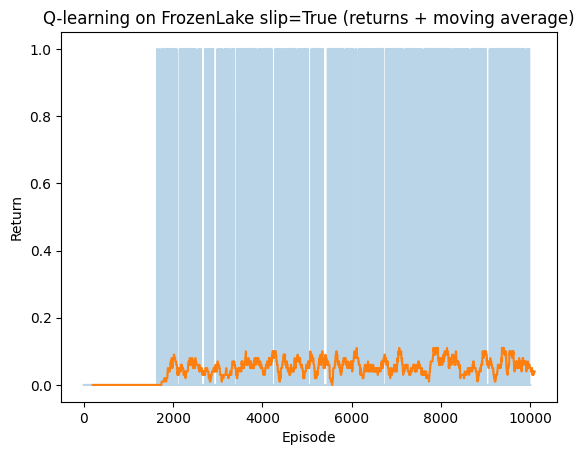

In [187]:
def moving_average(x, w=1):
    x = np.asarray(x, dtype=float)
    if len(x) < w:
        return x
    return np.convolve(x, np.ones(w)/w, mode="valid")

Q, returns = train_q_learning(episodes=10000, alpha=0.8, gamma=0.9, eps=0.3) # The one in the graph

ma = moving_average(returns, w=100)

plt.figure()
plt.plot(returns, alpha=0.3)
plt.plot(np.arange(len(ma)) + 200 - 1, ma)
plt.xlabel("Episode")
plt.ylabel("Return")
plt.title("Q-learning on FrozenLake slip=True (returns + moving average)")
plt.show()


Mean return : 0.0491
Number of successes: 491.0


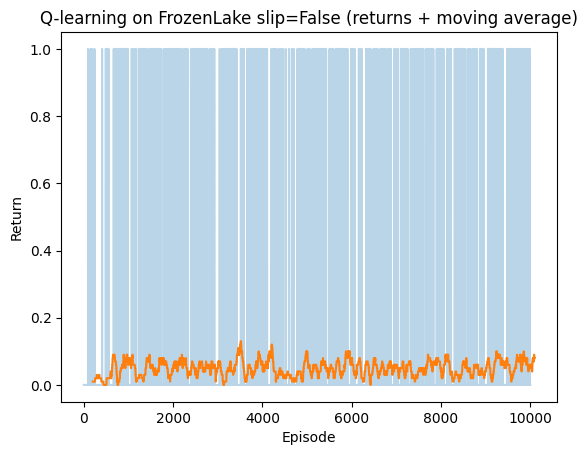

In [182]:
env_no_slip = gym.make("FrozenLake-v1", is_slippery=False)

Q, returns = train_q_learning(episodes=10000, alpha=0.95, gamma=0.8, eps=0.3)
print("Mean return :", returns.mean())
print("Number of successes:", np.sum(returns))

ma = moving_average(returns, w=100)

plt.figure()
plt.plot(returns, alpha=0.3)
plt.plot(np.arange(len(ma)) + 200 - 1, ma)
plt.xlabel("Episode")
plt.ylabel("Return")
plt.title("Q-learning on FrozenLake slip=False (returns + moving average)")
plt.show()


Extract policy from Q and evaluate

In [ ]:
def evaluate_policy(Q, episodes=2000, max_steps=100):
    total = 0.0
    for _ in range(episodes):
        s, info = env.reset()
        G = 0.0
        for _ in range(max_steps):
            a = int(np.argmax(Q[s]))
            s, r, terminated, truncated, info = env.step(a)
            G += r
            if terminated or truncated:
                break
        total += G
    return total / episodes

print("Avg return (greedy policy):", evaluate_policy(Q))


Avg return (greedy policy): 0.0


#### Exercises:

- Try α=0.1 vs α=0.5 vs α=1.0. What happens?
    - From the results, α=0.1 actually performed the best, getting 365 successes with ε=0.3. α=0.5 got 271 and α=1.0 only got 135 with the same epsilon. So lower alpha was better here. That makes sense because FrozenLake is slippery and stochastic, so when the same action can give different results, you want small cautious updates instead of completely overwriting what you learned. With α=1.0 the agent keeps forgetting previous experience which makes learning unstable.

- Try ε=0.01 vs 0.1 vs 0.3. What happens?
    - ε=0.01 gave 0 successes across every alpha value. ε=0.1 also gave 0 in most cases. ε=0.3 always gave the most successes. So for FrozenLake, you really need a lot of exploration. Because the lake is slippery and the agent can fall in holes in many places, with low epsilon the agent never stumbles on the goal by accident and never gets any reward signal to learn from. Without reward signal the Q-table never updates to anything useful and it just stays at 0. Only when exploring enough with ε=0.3 does the agent start finding the goal and getting something to learn from.

- Compare is_slippery=True vs False (deterministic). Which learns faster, and why?
    - When I did the testing, the results were quite different and also depended on hyper-parameters. But in general, the model that trains in a non-slippery environment learns faster. Because if it finds a correct path to take, that path will not change due to slipperiness. It stays the same, so the model can keep getting rewards from the same movements on that path, which makes learning faster. In slippery mode, the same action can lead to different next states, so the learning signal is noisier and it usually needs more episodes to converge.

#### Questions:


- Why is Q-learning called model-free? 

   - Because it does not need to know the environment beforehand and gets to know it during training. It does not need a precise model of how the environment works, like the transition probabilities or reward function. Instead, it learns from trying actions, seeing the rewards, and updating what it thinks is the best action in each state.


- Explain "exploration vs exploitation" in your own words.

    - Exploration is when the model does not just use the learned "best path" every time, but instead tries different actions to see what happens. Sometimes that can look random, and we need this because without testing new things and unexplored states in the environment, the model never knows if there is a better path than the one it has already learned for getting to the goal or maximizing its reward.

    - Exploitation is when the model uses its previous knowledge and acts according to what seemed like the best path last time in a certain state. This is important because if the model finds a really good action from a certain state, it benefits from remembering what worked well there and using it again if it ends up there another time.

- What is the "state-action explosion" limitation of tabular Q-learning?

    - The state-action explosion is when the Q-table becomes too large because the agent needs one Q-value (the expected future reward) for every state-action pair. If there are many states and many actions, the table grows very fast and needs much more memory, much more training data, and much more time to learn well. That is why tabular Q-learning does not scale well to very large or complex environments.
